In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

In [2]:
df = pd.read_csv("../data/processed/master.csv")

df.shape

(394, 33)

In [3]:
df.head(5)

,player_name,team_abbr,pos,age,G,GS,MP,FG%,3P%,FT%,...,salary,team_name,wins,losses,Win_PCT,home_record,road_record,conference,overall_rank,ws_per_million
0,Shai Gilgeous-Alexander,OKC,PG,26.0,76.0,76.0,34.2,0.519,0.375,0.898,...,35859950,Oklahoma City Thunder,68,14,0.829,35-6,32-8,West,1,0.465701
1,Giannis Antetokounmpo,MIL,PF,30.0,67.0,67.0,34.2,0.601,0.222,0.617,...,48787676,Milwaukee Bucks,48,34,0.585,27-14,20-20,East,11,0.235715
2,Nikola Jokic,DEN,C,29.0,70.0,70.0,36.7,0.576,0.417,0.800,...,51415938,Denver Nuggets,50,32,0.610,26-15,24-17,West,6,0.318967
3,Anthony Edwards,MIN,SG,23.0,79.0,79.0,36.3,0.447,0.395,0.837,...,42176400,Minnesota Timberwolves,49,33,0.598,25-16,24-17,West,10,0.199164
4,Jayson Tatum,BOS,PF,26.0,72.0,72.0,36.4,0.452,0.343,0.814,...,34848340,Boston Celtics,61,21,0.744,28-13,33-8,East,3,0.272610


## Salary distribution by position

In [4]:
df["pos"].unique()

<StringArray>
['PG', 'PF', 'C', 'SG', 'SF']
Length: 5, dtype: str

In [5]:
position_map = {
    "PG": "Point Guard",
    "SG": "Shooting Guard",
    "SF": "Small Forward",
    "PF": "Power Forward",
    "C": "Center"
}

df["position_full"] = df["pos"].map(position_map)

def millions(x, pos):
    return f"{x/1e6:.0f}"

In [31]:
############### helper functions -------------------------------------------
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np


def adjusted_r2(r2, n, k):
    return 1 - (1 - r2) * (n - 1) / (n - k -1)


def fit_n_pred(X, y):
    model = LinearRegression().fit(X, y)
    
    return model.predict(X)


def sse(y, preds):
    return np.sum((y - preds)**2)


def eval_features(df, features):
    adj_r2_scores = []
    sse_scores = []
    
    for pos, group in df.groupby("position_full"):
        if len(group) <= len(features) + 1:
            continue
        X = group[features]
        log_y = np.log(group["salary"])
        preds = fit_n_pred(X,log_y)

        r2 = r2_score(log_y, preds)
        adj = adjusted_r2(r2, n=len(group), k=len(features))
        adj_r2_scores.append(adj)

        sal_pred = np.exp(preds)
        # sal_pred = np.exp(preds + 0.5 * np.var(preds - log_y))
        sse_scores.append(sse(group["salary"], sal_pred))

    return {
        "adj_r2": np.mean(adj_r2_scores),
        "sse" : np.sum(sse_scores)
    }


def fit_position_model(df, features):
    if len(df) <= len(features) + 1:
        df = df.copy()
        df["expected_salary"] = np.nan
        return df
    df = df.copy()

    log_y = np.log(df["salary"])
    log_preds = fit_n_pred(df[features], log_y)
    df["expected_salary"] = np.exp(log_preds)
    return df

############### helper functions end ----------------------------------------

In [32]:
FEATURES = {
    "js_ws":    ["WS"],
    "js_vorp":  ["VORP"],
    "basic":    ["WS", "PTS", "age", "G"],
    "medium":   ["WS", "VORP", "PTS", "AST", "TRB", "age", "G"],
    "complex":  ["WS", "VORP", "BPM", "PTS", "AST", "TRB", "USG%", "age", "G"],
}


df_temp = df[df["G"] >= 20].copy() # removes players who didn't play a lot
# df_temp = df_temp[df_temp["WS"] > 0]  # Negative WS are net negatives
# the model gives funky numbers when we include them
# NOTE: this biases our regression upwards
# so not necessarily baseline salary
# salary that is conditional on being somehwat productive

print(f"{'Feature set':<12} {'Adj R²':>10} {'SSE':>20}")
print("-" * 45)
results = {}
for name, features in FEATURES.items():
    metrics = eval_features(df_temp, features)
    results[name] = metrics
    sse_billions = metrics["sse"] / 1e18  # salaries are large numbers
    print(f"  {name:<10} {metrics['adj_r2']:>10.3f} {sse_billions:>18.3f}B²")


chosen_features = FEATURES["complex"]

df_temp = (
    df_temp
    .groupby("position_full", group_keys=False)
    .apply(fit_position_model, features=chosen_features)
)



Feature set      Adj R²                  SSE
---------------------------------------------
  js_ws           0.324              0.061B²
  js_vorp         0.288              0.117B²
  basic           0.562              0.041B²
  medium          0.563              0.026B²
  complex         0.561              0.027B²


In [33]:
df_temp["position_full"] = df_temp["pos"].map(position_map)

In [34]:
# df_temp[df_temp["expected_salary"].isna()]

df_temp.loc[df_temp["expected_salary"] < 0, ["player_name", "position_full", "salary", "expected_salary"]]

,player_name,position_full,salary,expected_salary


In [35]:
df_temp["salary_diff"]      = df_temp["expected_salary"] - df_temp["salary"]  # positive = underpaid
df_temp["value_ratio"]      = df_temp["salary"] / df_temp["expected_salary"]  # < 1 = underpaid
df_temp["value_score"] = (df_temp["expected_salary"] - df_temp["salary"]) / df_temp["expected_salary"]
df_temp["ws_per_million"]   = df_temp["WS"]   / (df_temp["salary"] / 1_000_000)
df_temp["vorp_per_million"] = df_temp["VORP"]  / (df_temp["salary"] / 1_000_000)
df_temp["bpm_per_million"]  = df_temp["BPM"]   / (df_temp["salary"] / 1_000_000)

print(f"\nChosen features: {chosen_features}")
print(f"Players in analysis dataset: {len(df_temp)}")
print(f"Players excluded (G < 20, WS <= 0, or too few per position): {len(df) - len(df_temp)}")



Chosen features: ['WS', 'VORP', 'BPM', 'PTS', 'AST', 'TRB', 'USG%', 'age', 'G']
Players in analysis dataset: 361
Players excluded (G < 20, WS <= 0, or too few per position): 33


In [36]:
df_temp[df_temp["value_score"] > 0]

,player_name,team_abbr,pos,age,G,GS,MP,FG%,3P%,FT%,...,conference,overall_rank,ws_per_million,expected_salary,position_full,salary_diff,value_ratio,value_score,vorp_per_million,bpm_per_million
0,Shai Gilgeous-Alexander,OKC,PG,26.0,76.0,76.0,34.2,0.519,0.375,0.898,...,West,1,0.465701,6.989207e+07,Point Guard,3.403212e+07,0.513076,0.486924,0.248188,0.320692
1,Giannis Antetokounmpo,MIL,PF,30.0,67.0,67.0,34.2,0.601,0.222,0.617,...,East,11,0.235715,5.570086e+07,Power Forward,6.913180e+06,0.875887,0.124113,0.135280,0.194721
5,Kevin Durant,PHO,PF,36.0,62.0,62.0,36.5,0.527,0.430,0.839,...,West,21,0.101604,1.135613e+08,Power Forward,6.238225e+07,0.450673,0.549327,0.058618,0.062526
7,Cade Cunningham,DET,PG,23.0,70.0,70.0,35.0,0.469,0.356,0.846,...,East,14,0.423222,2.615223e+07,Point Guard,1.221157e+07,0.533058,0.466942,0.265411,0.279757
8,Jalen Brunson,NYK,PG,28.0,65.0,65.0,35.4,0.488,0.383,0.821,...,East,5,0.332532,5.922012e+07,Point Guard,3.426012e+07,0.421478,0.578522,0.124199,0.132212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
359,Taj Gibson,CHO,C,39.0,37.0,11.0,11.1,0.495,0.500,0.600,...,East,28,0.191615,2.534305e+06,Center,4.467864e+05,0.823705,0.176295,-0.143711,-2.538899
363,Josh Minott,MIN,SF,22.0,46.0,0.0,6.0,0.489,0.326,0.895,...,West,10,0.445611,2.472478e+06,Small Forward,4.527786e+05,0.816873,0.183127,0.148537,1.089271
365,Anthony Gill,WAS,PF,32.0,51.0,0.0,7.8,0.489,0.323,0.660,...,East,29,0.223445,4.138267e+06,Power Forward,1.900576e+06,0.540731,0.459269,-0.134067,-2.011002
367,Pat Spencer,GSW,PG,28.0,39.0,0.0,6.4,0.406,0.227,0.733,...,West,11,0.683667,2.143630e+06,Point Guard,1.704820e+06,0.204704,0.795296,0.000000,-3.646225


In [37]:
df_temp[["ws_per_million", "vorp_per_million", "bpm_per_million"]].head()

,ws_per_million,vorp_per_million,bpm_per_million
0,0.465701,0.248188,0.320692
1,0.235715,0.135280,0.194721
2,0.318967,0.190602,0.258675
3,0.199164,0.109066,0.101953
4,0.272610,0.137740,0.149218


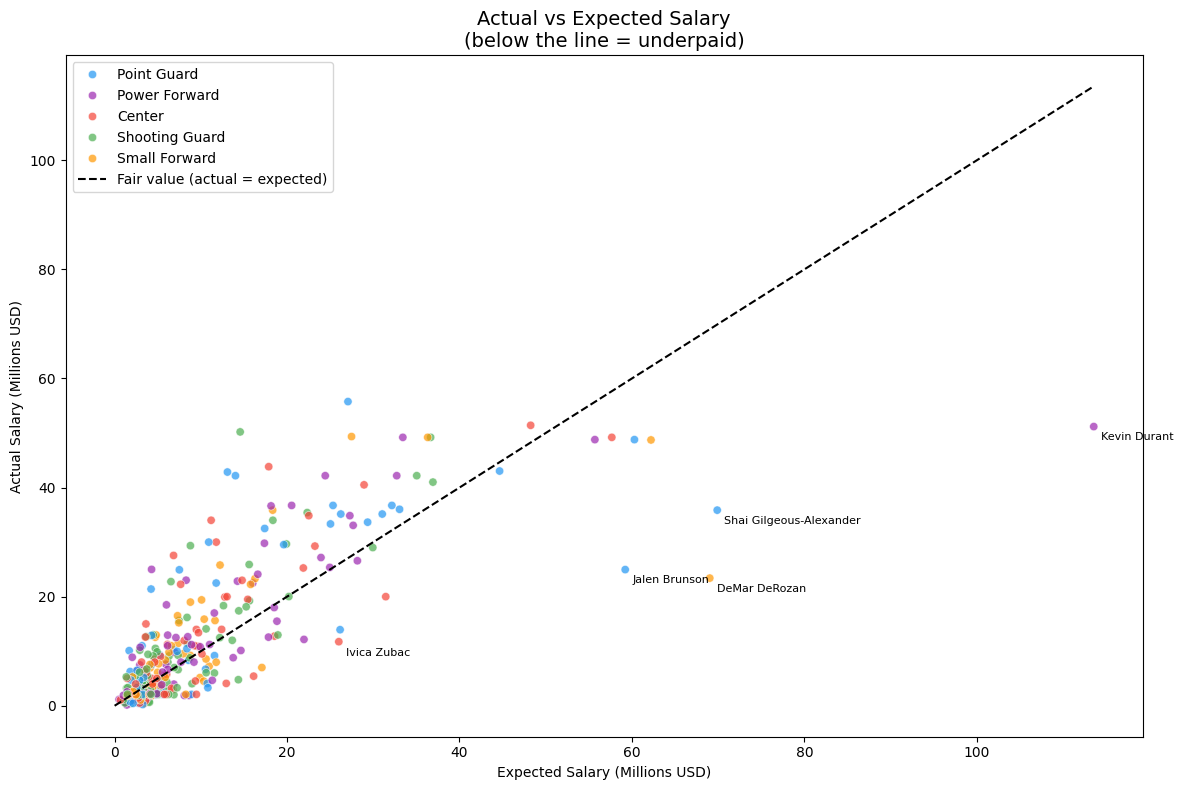

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

color = {
    "Point Guard": "#2196F3", "Shooting Guard": "#4CAF50",
    "Small Forward": "#FF9800", "Power Forward": "#9C27B0", "Center": "#F44336"
}

sns.scatterplot(data=df_temp, x="expected_salary", y="salary",
                hue="position_full", palette=color, alpha=0.7, ax=ax)

# Diagonal = perfectly paid
max_sal = max(df_temp["expected_salary"].max(), df_temp["salary"].max())
ax.plot([0, max_sal], [0, max_sal], color="black", linewidth=1.5,
        linestyle="--", label="Fair value (actual = expected)")

# Label the 5 most underpaid (furthest below the line)
most_underpaid = df_temp.nlargest(5, "salary_diff")
for _, row in most_underpaid.iterrows():
    ax.annotate(row["player_name"], (row["expected_salary"], row["salary"]),
                textcoords="offset points", xytext=(5, -10), fontsize=8)

ax.set_title("Actual vs Expected Salary\n(below the line = underpaid)", fontsize=14)
ax.set_xlabel("Expected Salary (Millions USD)")
ax.set_ylabel("Actual Salary (Millions USD)")
ax.xaxis.set_major_formatter(FuncFormatter(millions))
ax.yaxis.set_major_formatter(FuncFormatter(millions))
ax.legend()

plt.tight_layout()
plt.show()

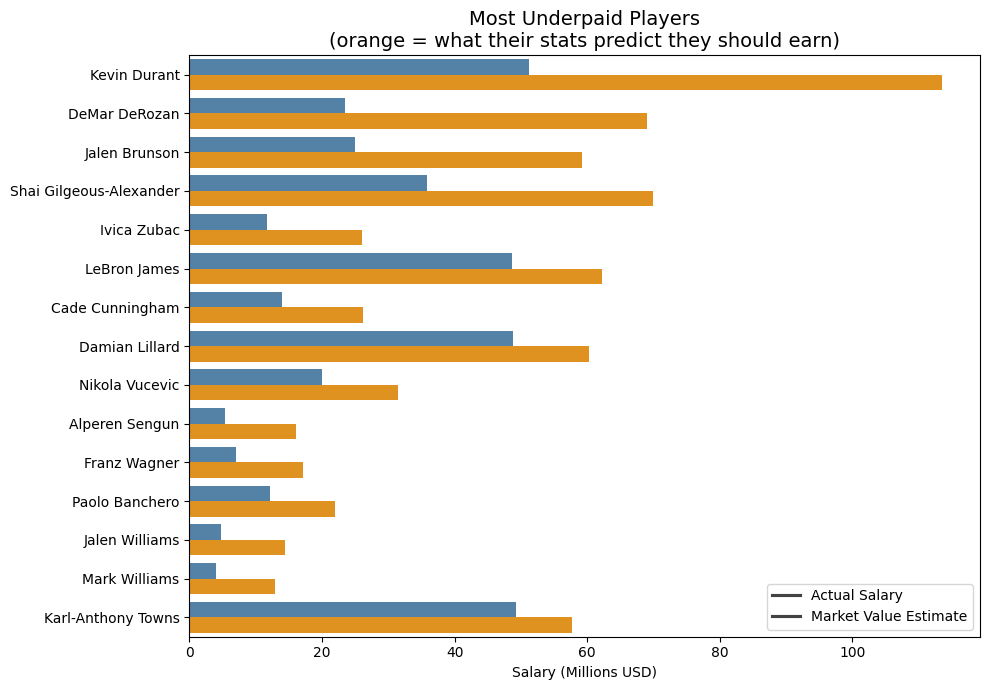

In [ ]:
top15 = df_temp.nlargest(15, "salary_diff")


# Side-by-side actual vs expected salary bars
plot_df = top15.melt(id_vars="player_name",
                     value_vars=["salary", "expected_salary"],
                     var_name="type", value_name="amount")

plot_df["type"] = plot_df["type"].map({
    "salary": "Actual Salary",
    "expected_salary": "Market Value Estimate"
})

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(data=plot_df, x="amount", y="player_name",
            hue="type", ax=ax,
            palette={"Actual Salary": "steelblue", "Market Value Estimate": "#FF9800"})

ax.set_title("Most Underpaid Players\n(orange = what their stats predict they should earn)", fontsize=14)
ax.set_xlabel("Salary (Millions USD)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(FuncFormatter(millions))
ax.legend(["Actual Salary", "Market Value Estimate"])

plt.tight_layout()
plt.show()

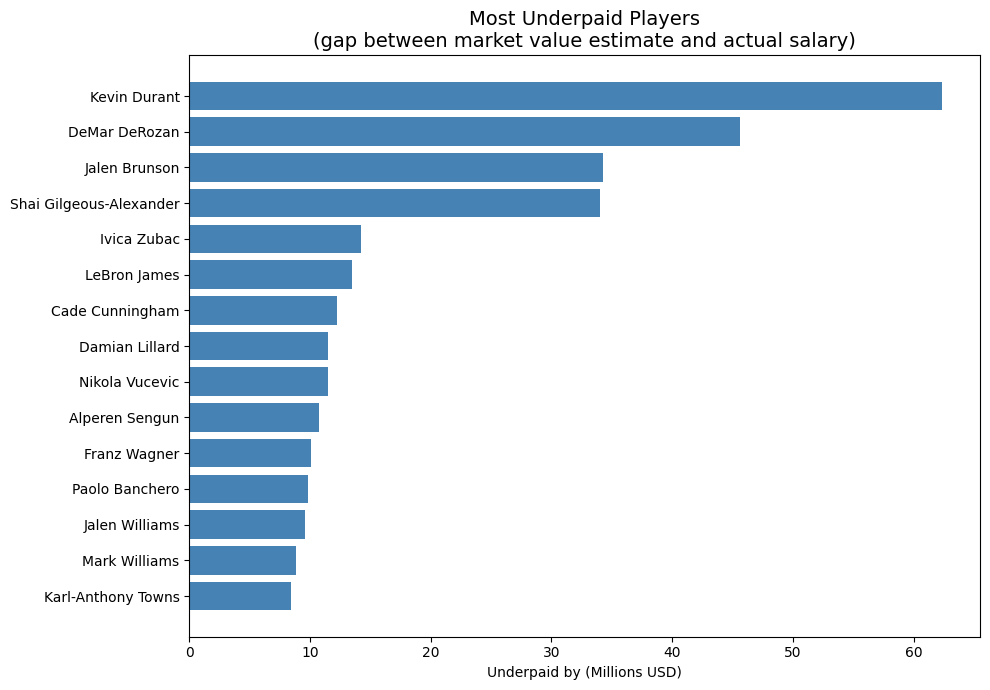

In [41]:
top15 = df_temp.nlargest(15, "salary_diff").sort_values("salary_diff")

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(top15["player_name"], top15["salary_diff"] / 1_000_000, color="steelblue")

ax.set_title("Most Underpaid Players\n(gap between market value estimate and actual salary)", fontsize=14)
ax.set_xlabel("Underpaid by (Millions USD)")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig("../results/most_underpaid_gap.png", dpi=150)
plt.show()

## Mean vs Median salary by position

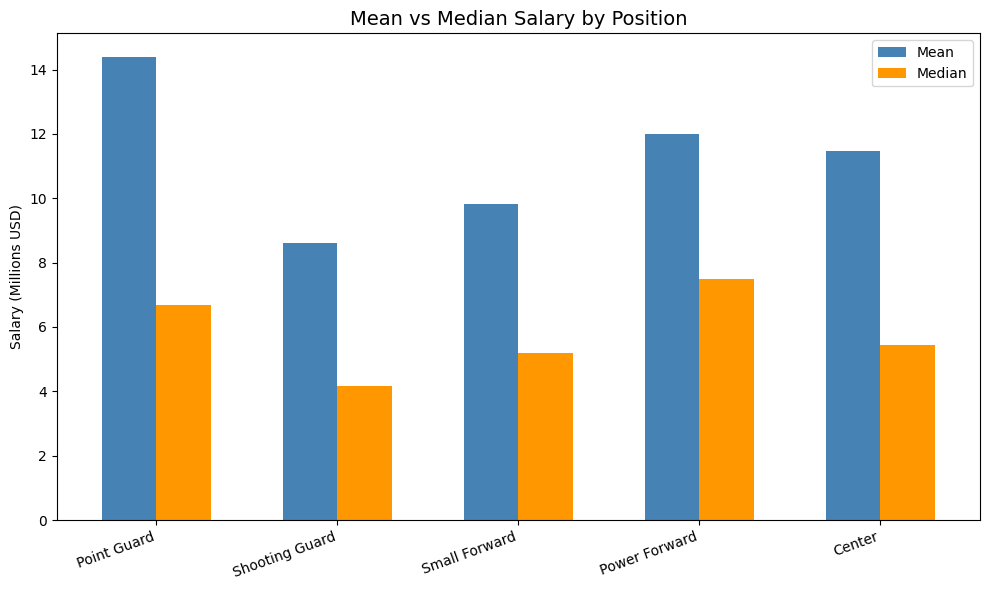

In [13]:
fig, ax = plt.subplots(figsize=(10,6))

pos_order = ["Point Guard", "Shooting Guard", "Small Forward", "Power Forward", "Center"]
salary_stats = df.groupby("position_full")["salary"].agg(["mean", "median"]).loc[pos_order]
salary_stats = salary_stats / 1_000_000

salary_stats.plot(kind="bar", 
                  ax=ax, 
                  color=["steelblue", "#FF9800"], 
                  width=0.6)

ax.set_title("Mean vs Median Salary by Position", fontsize=14) # gap shows how much stars skew the average
ax.set_xlabel("")
ax.set_ylabel("Salary (Millions USD)")
ax.set_xticklabels(pos_order, rotation=20, ha="right")
ax.legend(["Mean", "Median"])

plt.tight_layout()
plt.show()

## Top 15 underpaid by vorp_per_million vs ws_per_million

In [14]:
top_vorp = set(df_temp.nlargest(15, "vorp_per_million")["player_name"])
top_ws = set(df_temp.nlargest(15, "ws_per_million")["player_name"])
overlap = top_vorp & top_ws
print(f"Players in both top-15 lists {len(overlap)} total: {sorted(overlap)}")



Players in both top-15 lists 8 total: ['Jordan Goodwin', 'Keon Ellis', 'Luke Kornet', 'Quinten Post', 'Ryan Rollins', 'Scotty Pippen Jr.', 'Toumani Camara', 'Ty Jerome']


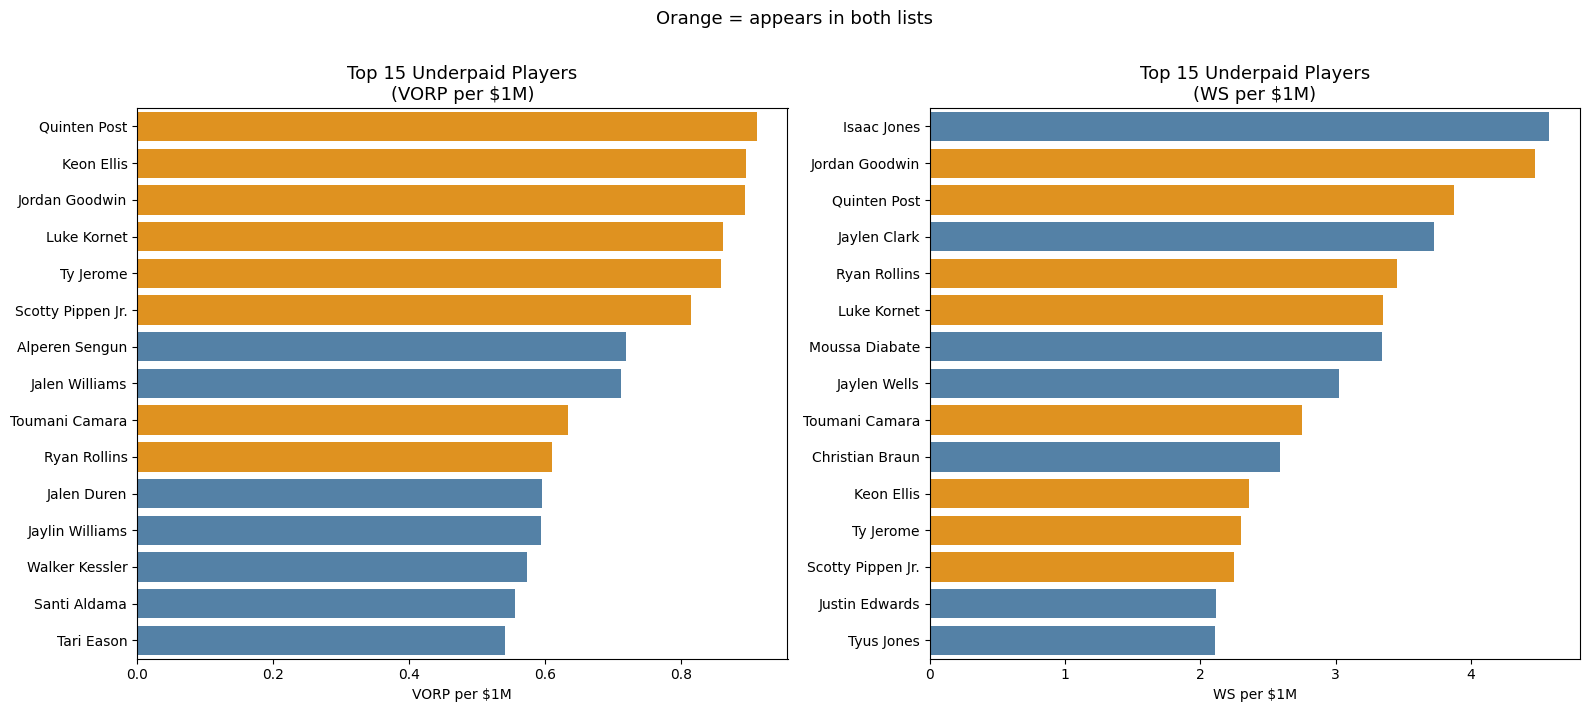

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16,7))

for ax, metric, label in zip(axes, ["vorp_per_million", "ws_per_million"], ["VORP per $1M","WS per $1M"]):
    top15 = df_temp.nlargest(15, metric)
    colors = ["#FF9800" if name in overlap else "steelblue" for name in top15["player_name"]]
    sns.barplot(data=top15, 
                x=metric, 
                y="player_name", 
                hue="player_name",
                ax=ax, palette=colors, 
                legend=False)
    ax.set_title(f"Top 15 Underpaid Players\n({label})", fontsize=13)
    ax.set_xlabel(label)
    ax.set_ylabel("")

fig.suptitle("Orange = appears in both lists", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

##  Team WS per million bar chart

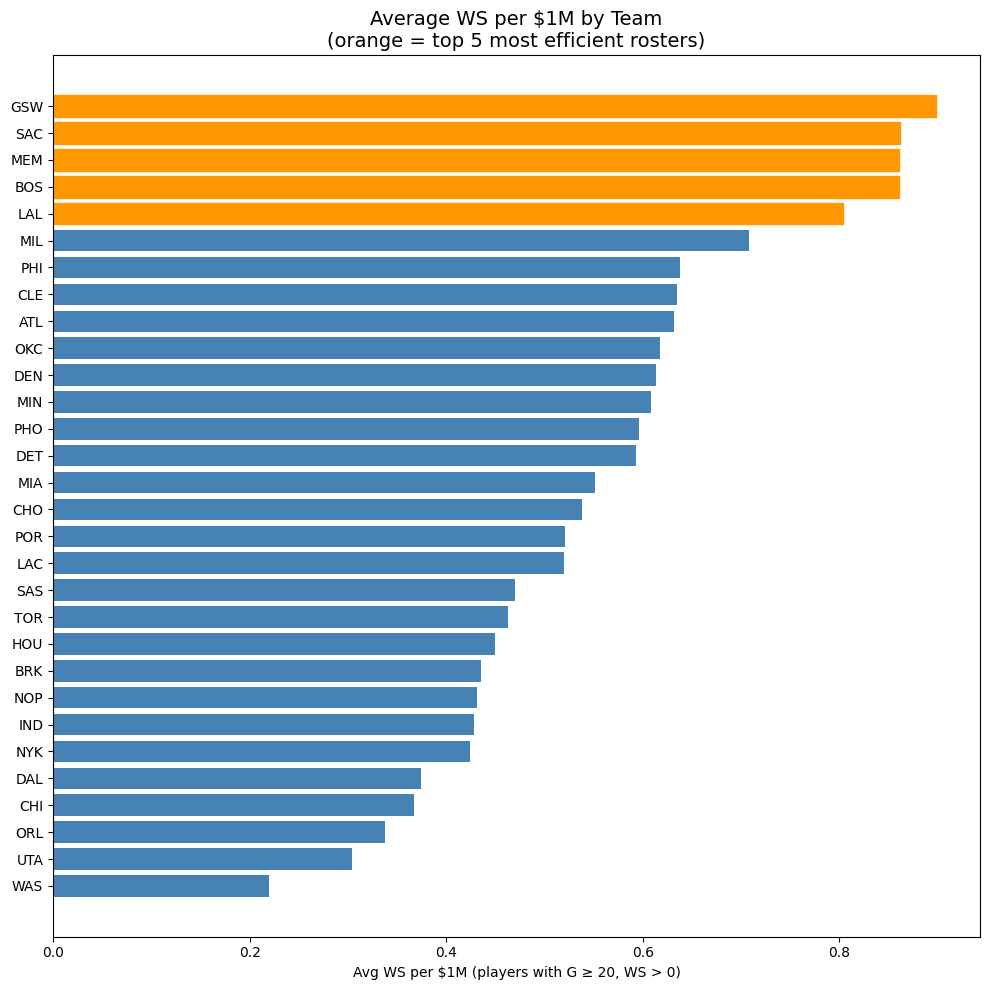

In [16]:
team_ws = df_temp.groupby("team_abbr")["ws_per_million"].mean().sort_values(ascending=True)
top5 = team_ws.nlargest(5).index.tolist()

fig, ax = plt.subplots(figsize=(10, 10))

bars = ax.barh(team_ws.index, team_ws.values, color="steelblue")
for bar, abbr in zip(bars, team_ws.index):
    if abbr in top5:
        bar.set_color("#FF9800")

ax.set_title("Average WS per $1M by Team\n(orange = top 5 most efficient rosters)", fontsize=14)
ax.set_xlabel("Avg WS per $1M (players with G ≥ 20, WS > 0)")
ax.set_ylabel("")

plt.tight_layout()
plt.show()


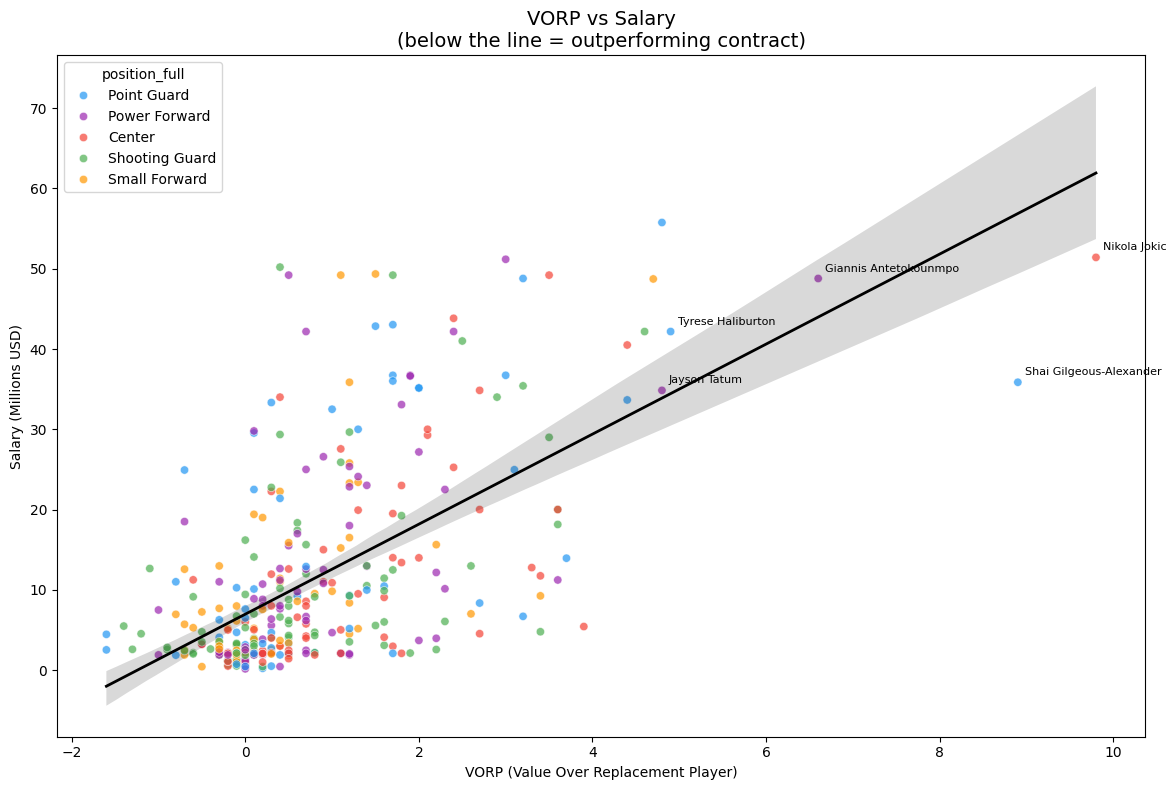

In [17]:
fig, ax = plt.subplots(figsize=(12, 8))

color = {
    "Point Guard": "#2196F3", "Shooting Guard": "#4CAF50",
    "Small Forward": "#FF9800", "Power Forward": "#9C27B0", "Center": "#F44336"
}

sns.scatterplot(data=df_temp, 
                x="VORP", 
                y="salary",
                hue="position_full", 
                palette=color, 
                alpha=0.7, ax=ax)

sns.regplot(data=df_temp, 
            x="VORP", 
            y="salary", 
            scatter=False,
            line_kws={"color": "black", "linewidth": 2}, 
            ax=ax)

top5_vorp = df_temp.nlargest(5, "VORP")
for _, row in top5_vorp.iterrows():
    ax.annotate(row["player_name"], (row["VORP"], row["salary"]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.set_title("VORP vs Salary\n(below the line = outperforming contract)", fontsize=14)
ax.set_xlabel("VORP (Value Over Replacement Player)")
ax.set_ylabel("Salary (Millions USD)")
ax.yaxis.set_major_formatter(FuncFormatter(millions))  # y-axis only, not x

plt.tight_layout()
plt.show()

## Dot Plot

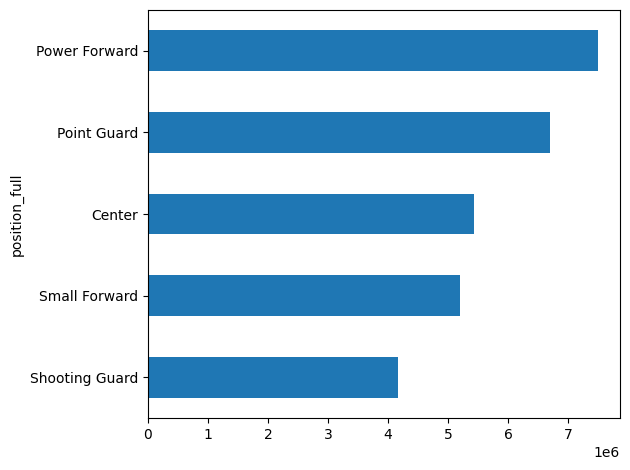

In [18]:
median_salary = df.groupby("position_full")["salary"].median().sort_values()

median_salary.plot(kind="barh")
plt.tight_layout()
plt.show()

## Boxplot + stripplot

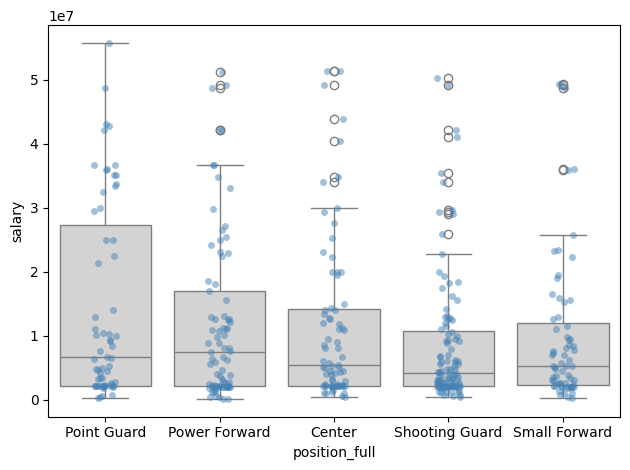

In [19]:
sns.boxplot(data=df, x="position_full", y="salary", color="lightgray")
sns.stripplot(data=df, x="position_full", y="salary", color="steelblue", alpha=0.5)
plt.tight_layout()
plt.show()

## team salary efficiency vs win %

In [20]:
team = df.groupby(["team_abbr", "team_name", "Win_PCT"]).agg(
    total_salary=("salary", "sum"),
    total_ws=("WS", "sum")
).reset_index()

team["team_ws_per_million"] = team["total_ws"] / (team["total_salary"] / 1000000)

In [21]:
# team["Win_PCT"] = team["Win_PCT"] * 100

In [22]:
team.head(5)

,team_abbr,team_name,Win_PCT,total_salary,total_ws,team_ws_per_million
0,ATL,Atlanta Hawks,0.488,124717289,32.9,0.263797
1,BOS,Boston Celtics,0.744,190264937,62.3,0.327438
2,BRK,Brooklyn Nets,0.317,78108487,20.0,0.256054
3,CHI,Chicago Bulls,0.476,123018981,30.8,0.250368
4,CHO,Charlotte Hornets,0.232,126061478,18.1,0.143581


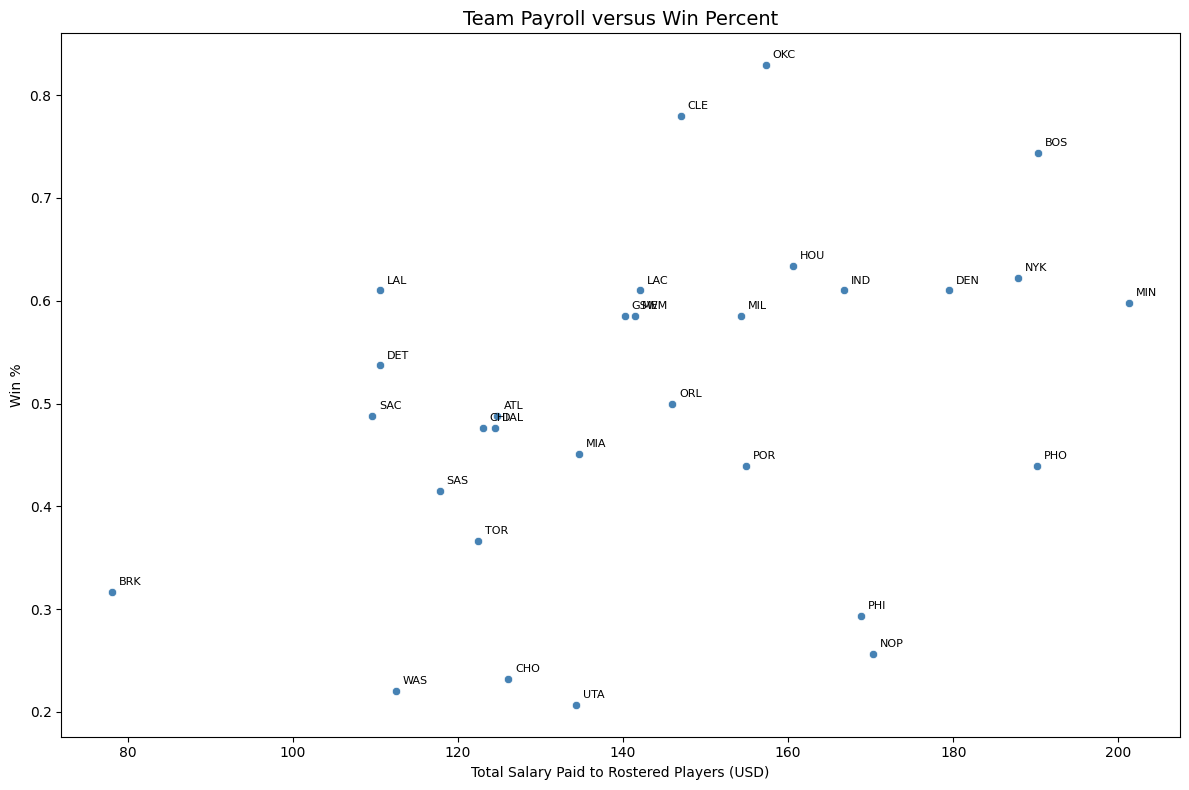

In [23]:
fig, ax = plt.subplots(figsize=(12,8))

sns.scatterplot(data=team,
            x="total_salary",
            y="Win_PCT",
            ax=ax, 
            color="steelblue")

# Label each dot with team abbreviation
for _, row in team.iterrows():
    ax.annotate(row["team_abbr"], (row["total_salary"], row["Win_PCT"]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.set_title("Team Payroll versus Win Percent", fontsize=14)
ax.set_xlabel("Total Salary Paid to Rostered Players (USD)")
ax.set_ylabel("Win %")
ax.xaxis.set_major_formatter(FuncFormatter(millions))

plt.tight_layout()
plt.show()

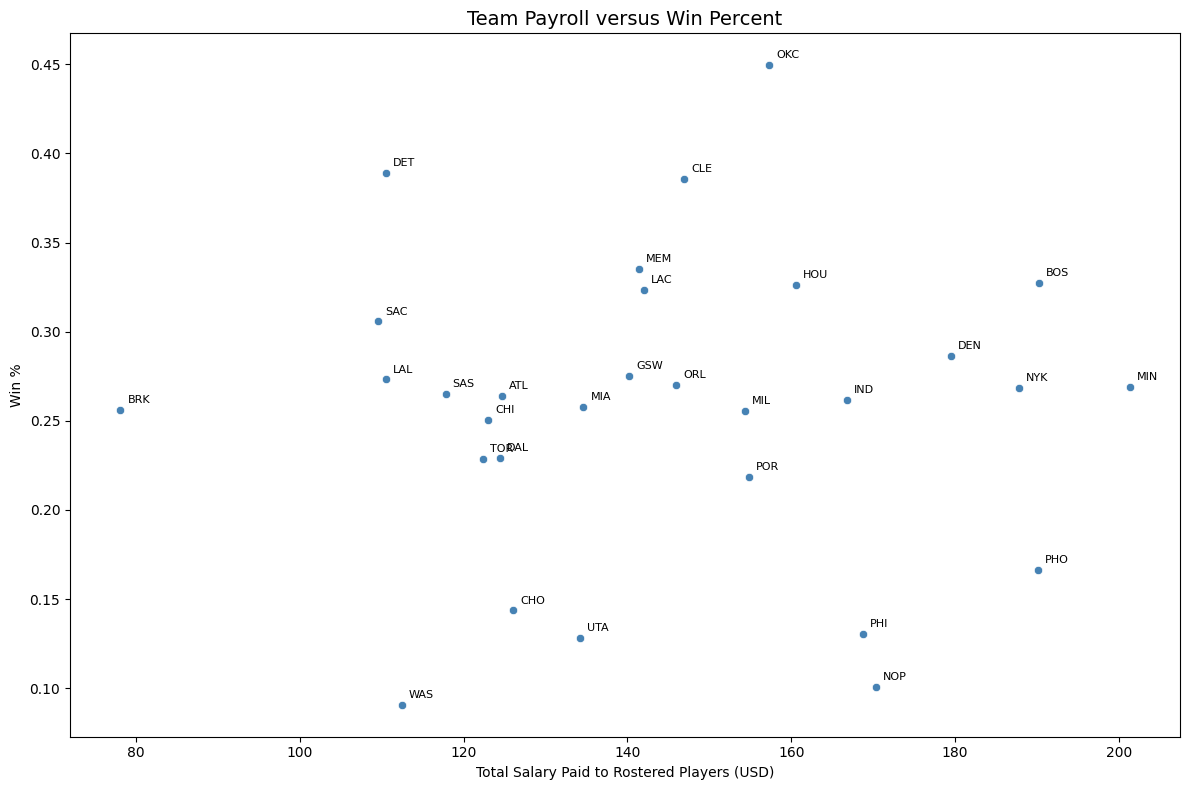

In [24]:
fig, ax = plt.subplots(figsize=(12,8))

sns.scatterplot(data=team,
            x="total_salary",
            y="team_ws_per_million",
            ax=ax, 
            color="steelblue")

# Label each dot with team abbreviation
for _, row in team.iterrows():
    ax.annotate(row["team_abbr"], (row["total_salary"], row["team_ws_per_million"]),
                textcoords="offset points", xytext=(5, 5), fontsize=8)

ax.set_title("Team Payroll versus Win Percent", fontsize=14)
ax.set_xlabel("Total Salary Paid to Rostered Players (USD)")
ax.set_ylabel("Win %")
ax.xaxis.set_major_formatter(FuncFormatter(millions))

plt.tight_layout()
plt.show()

## Top 20 Undervalued players by WS

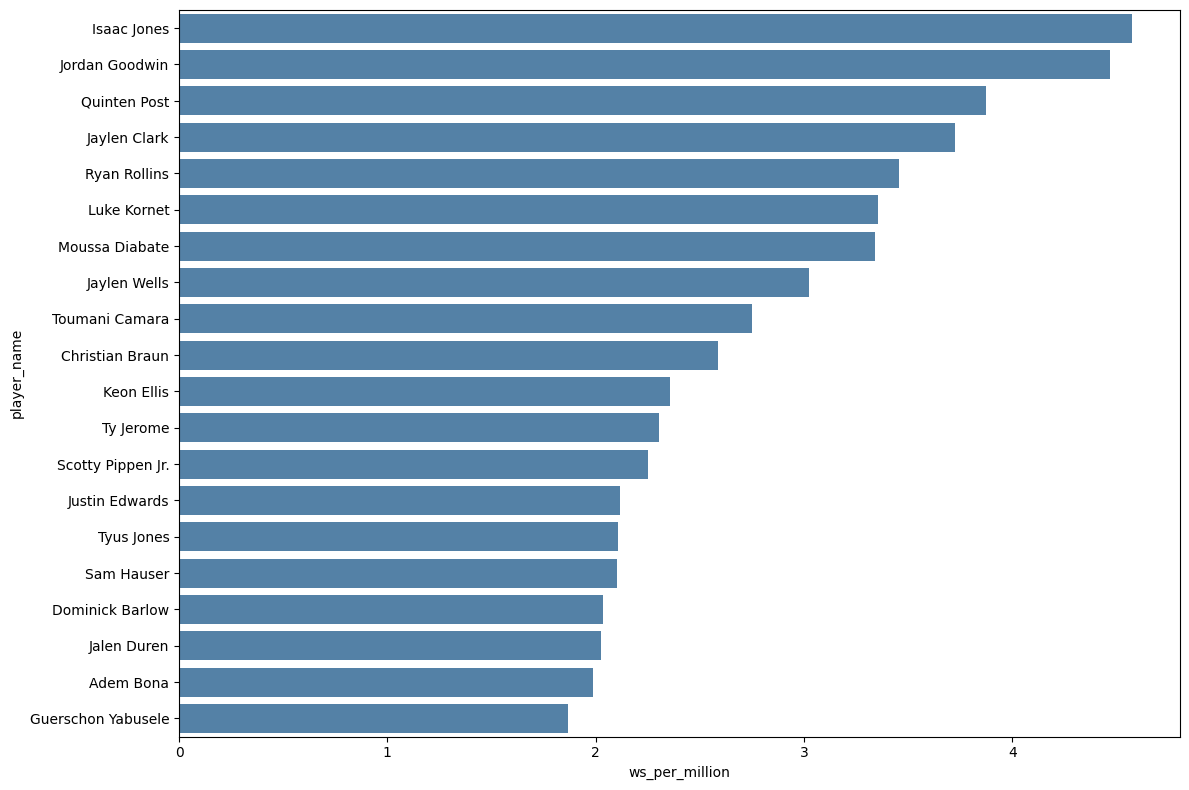

In [25]:
fig, ax = plt.subplots(figsize=(12,8))

top20 = df.nlargest(20, "ws_per_million")

sns.barplot(data=top20, 
            x="ws_per_million", 
            y="player_name",
            ax=ax,
            color="steelblue")

plt.tight_layout()
plt.show()

## Correlation Heatmap

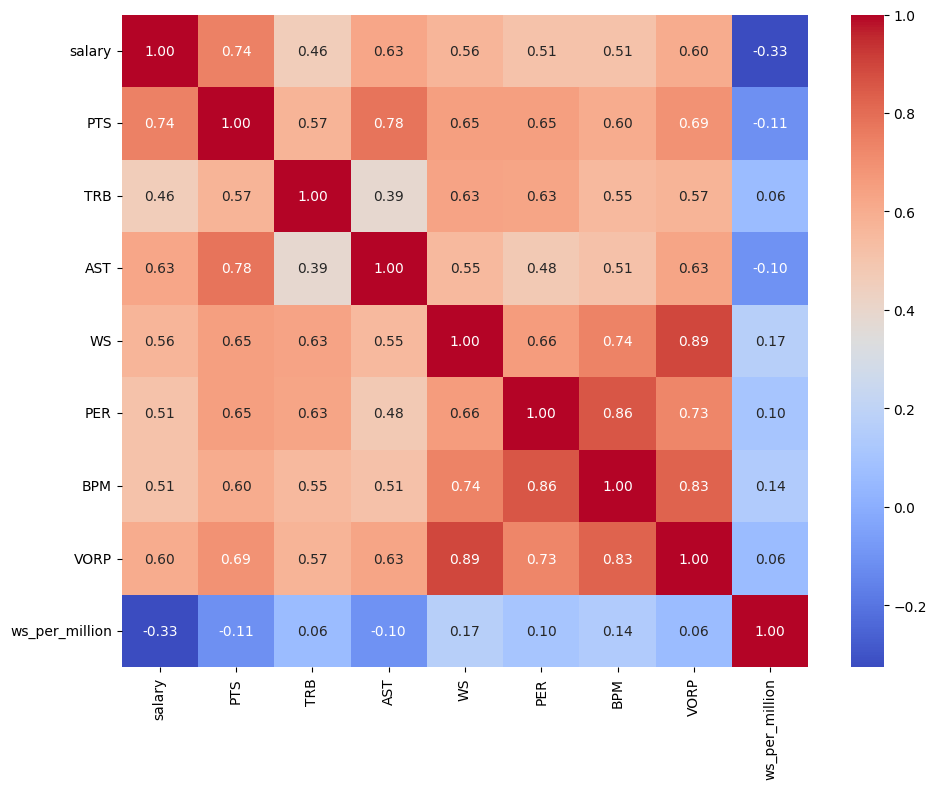

In [26]:
cols =["salary", "PTS", "TRB", "AST", "WS", "PER", "BPM", "VORP", "ws_per_million"]

fig, ax = plt.subplots(figsize=(10,8))

sns.heatmap(df[cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)

plt.tight_layout()
plt.show()

## Top 20 Undervalued players by WS and Position

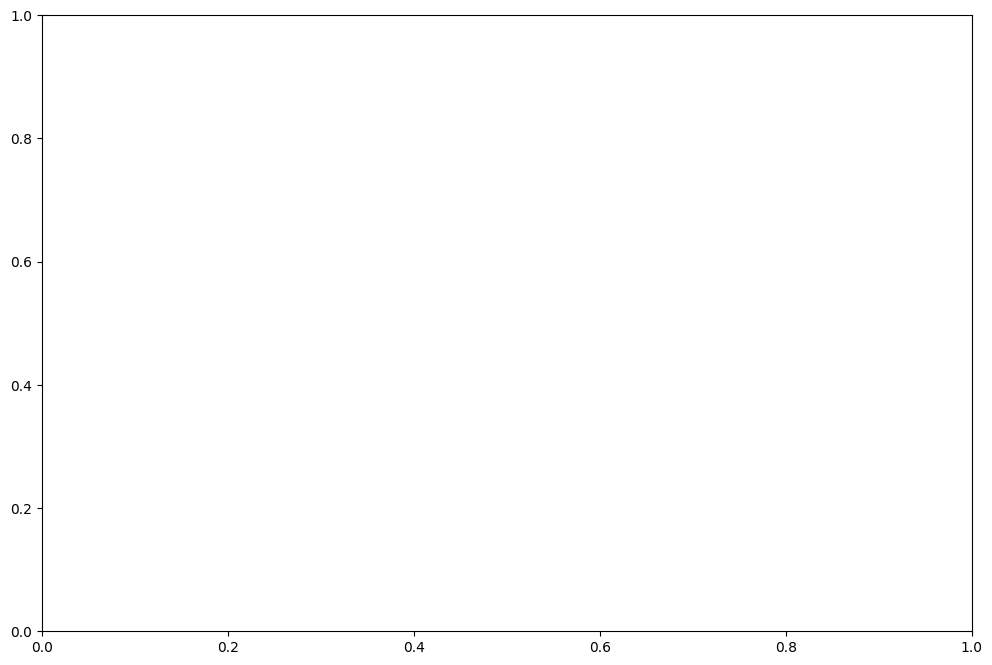

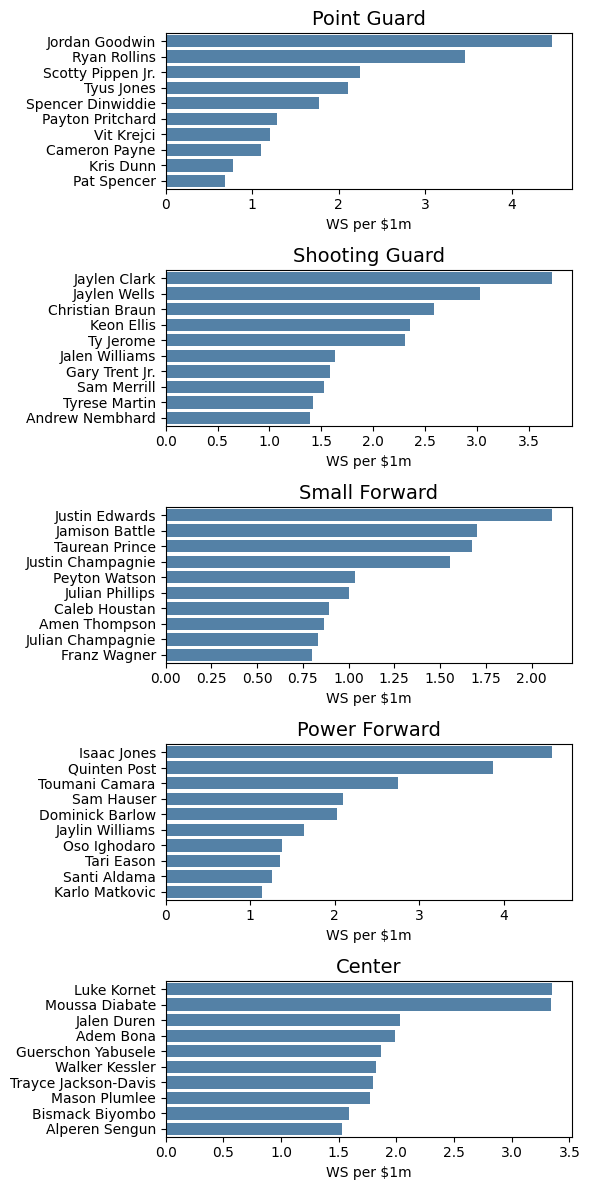

In [27]:
fig, ax = plt.subplots(figsize=(12,8))

df_temp = df[df["G"] >= 20].copy()

order = ["Point Guard", "Shooting Guard", "Small Forward", "Power Forward", "Center"]

fig, axes = plt.subplots(5, 1, figsize=(6,12))

for ax, pos in zip(axes, order):
    pos_df = df_temp[df_temp["position_full"] == pos].nlargest(10, "ws_per_million")
    sns.barplot(data=pos_df, 
                x="ws_per_million", 
                y="player_name",
                ax=ax,
                color="steelblue")
    ax.set_title(f"{pos}", fontsize=14)
    ax.set_xlabel("WS per $1m")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

# Regression

## Salary vs WS

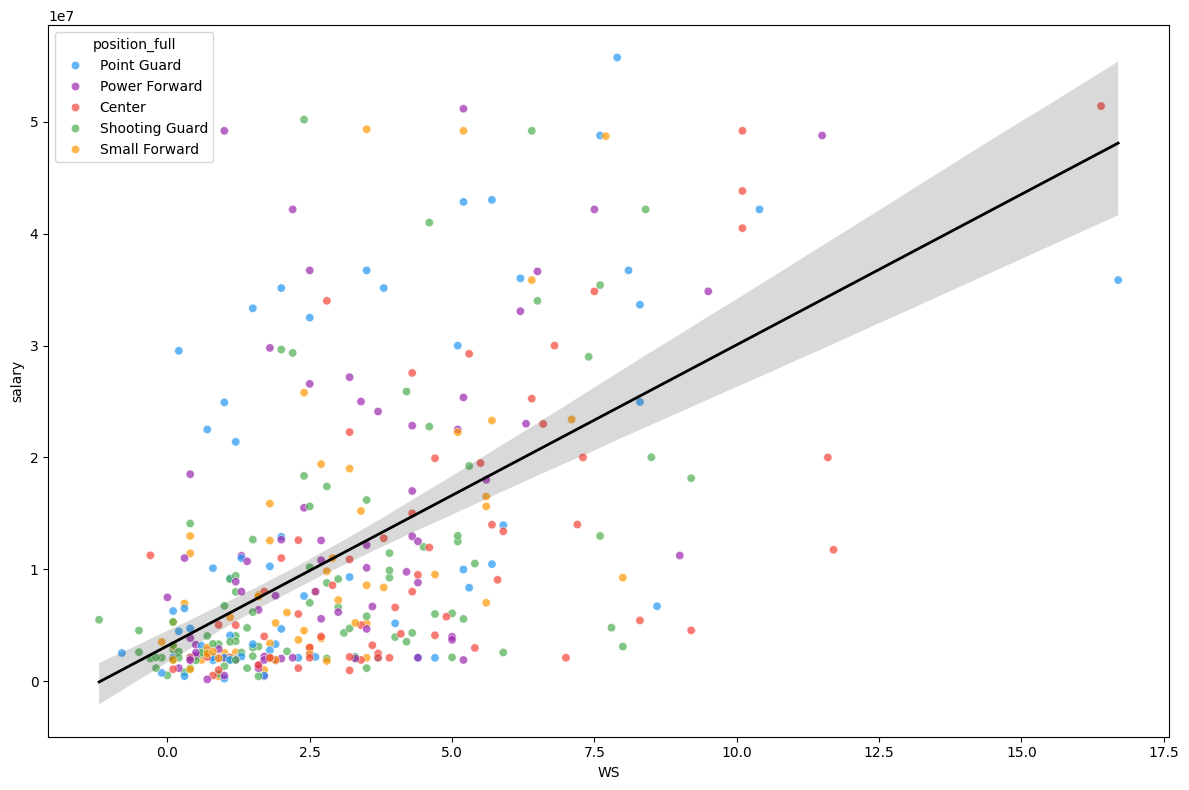

In [28]:
fig, ax = plt.subplots(figsize=(12,8))

df_temp = df[df["G"] >= 20].copy()

color = {
    "Point Guard": "#2196F3",
    "Shooting Guard": "#4CAF50",
    "Small Forward": "#FF9800",
    "Power Forward": "#9C27B0",
    "Center": "#F44336"
}
# scatter plot
sns.scatterplot(data=df_temp, 
                x="WS", 
                y="salary",
                hue="position_full",
                palette=color,
                alpha=0.7,
                ax=ax)
# regression line
sns.regplot(data=df_temp, 
                x="WS", 
                y="salary",
                scatter=False,
                line_kws={"color": "black", "linewidth": 2},
                ax=ax)

plt.tight_layout()
plt.show()


NameError: name 'g' is not defined

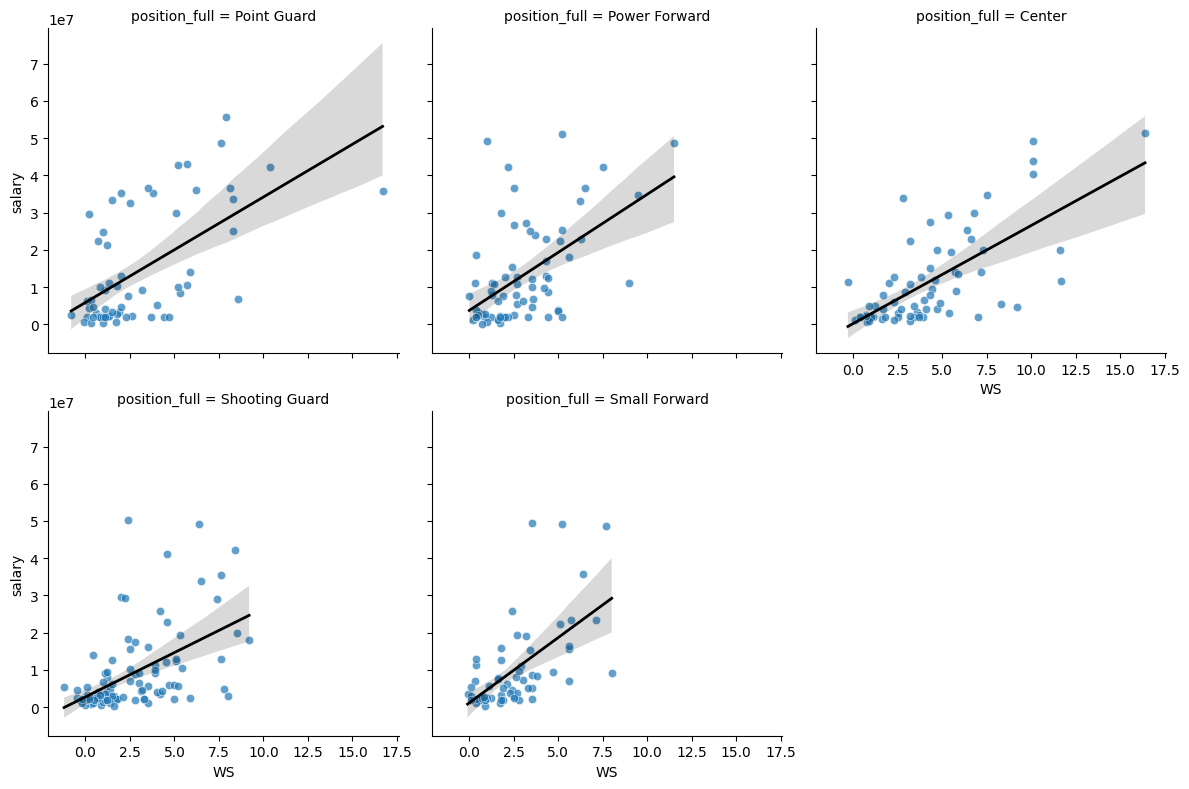

In [29]:
temp = sns.FacetGrid(df_temp, col="position_full", col_wrap=3, height=4)

temp.map_dataframe(
    sns.scatterplot,
    x="WS", 
    y="salary",
    alpha=0.7,
)
temp.map_dataframe(
    sns.regplot,
    x="WS", 
    y="salary",
    scatter=False,
    line_kws={"color": "black", "linewidth": 2}
)

g.set_titles("{col_name}")
g.tight_layout()
plt.show()

## 